# Phase 1 — Baseline CarDD : trois lignes de référence

Objectif : produire une **référence chiffrée honnête** pour la détection de type de dégât sur
photos de carrosserie. Tout ce qui suivra (phase 2 : résolution, seuils, architecture,
augmentation) se comparera à ce tableau.

## Les cinq décisions, prises avant d'écrire une ligne de code

| # | question | réponse | pourquoi |
|---|---|---|---|
| 1 | quelle cible ? | **multi-étiquette, 6 types de dégât** — le binaire « abîmé / pas abîmé » est dérivé à l'inférence | CarDD ne contient **aucune voiture intacte** (0 image sans annotation) : un binaire entraîné dessus répondrait toujours « abîmé ». Et 38 % des images portent ≥ 2 types de dégât, qu'une cible mono-étiquette obligerait à jeter. |
| 2 | quels découpages ? | **ceux de CarDD** : 2 816 / 810 / 374 | Aucune fuite détectable (0 nom commun, 0 doublon md5) et résultats comparables à la littérature. `test2017` reste **fermé** jusqu'à la phase 3. |
| 3 | quelle métrique arbitre ? | **macro-F1** | Chaque classe pèse 1/6 : abandonner `tire flat` (219 images d'entraînement) devient visible. L'exactitude est refusée — ne jamais prédire `tire flat` donnerait déjà 92,7 %. |
| 4 | quelle baseline ? | **trois lignes** : planchers triviaux / backbone gelé / affinage complet | Un chiffre seul ne démontre rien. Trois lignes racontent ce que le transfert d'apprentissage apporte, et à quel prix. |
| 5 | quand arrêter ? | **budget fixe de 10 époques**, poids de la meilleure époque sur validation | Budget égal = comparaison équitable. La courbe complète **montre** le surapprentissage au lieu de le couper avant qu'il se voie. |

**Réglages de référence** (aucun n'est un levier de cette phase) : entrée 224 px, normalisation
ImageNet, lots de 32, optimiseur Adam, pas d'apprentissage 1e-3 pour la tête seule et 1e-4 pour
l'affinage complet, perte d'entropie croisée binaire pondérée par `pos_weight`, seuil 0,5,
graine fixée, aucune augmentation de données.

In [1]:
import sys, time
sys.path.insert(0, "../../src")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from cardd import CarDDMultiLabel, CLASSES
from device import get_device
import train_cardd as tc

RACINE = "../../data/cardd/raw/CarDD_release/CarDD_COCO"
GRAINE, TAILLE, LOTS, EPOQUES = 0, 224, 32, 10
# num_workers=0 : le décodage JPEG coûte ~29 s/époque en séquentiel, mesuré — suffisant,
# et cela évite les soucis de multiprocessing 'spawn' de macOS dans un noyau Jupyter.
WORKERS = 0

tc.set_seed(GRAINE)
device = get_device()
print("device :", device, "| torch", torch.__version__)

device : mps | torch 2.13.0


## 1. Les données

Trois découpages fournis par les auteurs de CarDD, utilisés tels quels. On vérifie que les
effectifs correspondent bien aux annotations COCO avant d'entraîner quoi que ce soit : une erreur
de chargement silencieuse invaliderait tout le reste.

`test2017` n'est **pas** chargé dans ce carnet. Chaque décision prise en regardant un jeu le
contamine ; le test doit rester vierge pour la phase 3, où il ne sera mesuré qu'une seule fois.

In [2]:
tf = tc.build_transforms(TAILLE)
train_ds = CarDDMultiLabel(RACINE, "train", tf)
val_ds   = CarDDMultiLabel(RACINE, "val", tf)
print(f"train : {len(train_ds)} images | validation : {len(val_ds)} images")

y_tr, y_va = train_ds.label_matrix().numpy(), val_ds.label_matrix().numpy()
effectifs = pd.DataFrame({
    "train": y_tr.sum(0).astype(int),
    "part train": (y_tr.mean(0) * 100).round(1),
    "validation": y_va.sum(0).astype(int),
    "pos_weight": train_ds.pos_weight().numpy().round(2),
}, index=CLASSES).sort_values("train", ascending=False)

print(f"\nimages sans aucun dégât : train {int((y_tr.sum(1) == 0).sum())} | val {int((y_va.sum(1) == 0).sum())}")
print(f"images avec >= 2 types de dégât : train {(y_tr.sum(1) >= 2).mean()*100:.0f} % | val {(y_va.sum(1) >= 2).mean()*100:.0f} %")
effectifs

train : 2816 images | validation : 810 images

images sans aucun dégât : train 0 | val 0
images avec >= 2 types de dégât : train 38 % | val 38 %


,train,part train,validation,pos_weight
scratch,1507,53.500000,431,0.87
dent,1242,44.099998,352,1.27
lamp broken,489,17.400000,139,4.76
glass shatter,469,16.700001,134,5.00
crack,434,15.400000,122,5.49
tire flat,219,7.800000,59,11.86


**Lecture.** `scratch` (rayure) est environ 7 fois plus fréquent que `tire flat` (pneu à plat).
Sans correction, le réseau a intérêt à ne jamais prédire les classes rares : c'est rationnel, ça
minimise la perte. `pos_weight` = négatifs / positifs corrige ça en pondérant la perte par classe
— une erreur sur `tire flat` coûte ~13 fois plus qu'une erreur sur `scratch`.

Zéro image sans dégât : c'est la mesure qui a fermé la question 1 (pas de binaire possible ici).

## 2. Ligne 1 — les planchers triviaux

Deux modèles qui n'apprennent **rien**, pour savoir ce que « 0,56 de macro-F1 » vaut :

- **toujours oui** : tout est prédit positif. Rappel = 1 par construction, précision = prévalence
  de la classe. C'est le plus dur à battre sur les classes fréquentes.
- **fréquences** : chaque classe est tirée au hasard (loi de Bernoulli) à sa fréquence
  d'entraînement. C'est le hasard informé.

Coût : aucun entraînement. Sans ces lignes, un réseau à F1 = 0,70 sur `scratch` semblerait bon —
alors que « toujours oui » l'atteint sans rien comprendre, puisque `scratch` est présent dans 53 %
des images de validation.

In [3]:
lignes_synthese = []
for strategie in ("toujours_oui", "frequences"):
    probas, cibles = tc.plancher_probas(train_ds, val_ds, strategie, seed=GRAINE)
    scores = tc.evaluate(probas, cibles)
    lignes_synthese.append(tc.resume_ligne(f"plancher : {strategie}", scores))
    print(f"\n--- plancher « {strategie} » ---")
    display(scores)


--- plancher « toujours_oui » ---


,precision,rappel,F1,support
dent,0.4346,1.0,0.6059,352
scratch,0.5321,1.0,0.6946,431
crack,0.1506,1.0,0.2618,122
glass shatter,0.1654,1.0,0.2839,134
lamp broken,0.1716,1.0,0.2929,139
tire flat,0.0728,1.0,0.1358,59
macro,0.2545,1.0,0.3791,1237
micro,0.2545,1.0,0.4058,1237



--- plancher « frequences » ---


,precision,rappel,F1,support
dent,0.4641,0.4773,0.4706,352
scratch,0.5400,0.5476,0.5438,431
crack,0.1818,0.1967,0.1890,122
glass shatter,0.1429,0.1418,0.1423,134
lamp broken,0.1399,0.1439,0.1418,139
tire flat,0.0690,0.0678,0.0684,59
macro,0.2563,0.2625,0.2593,1237
micro,0.3723,0.3808,0.3765,1237


## 3. Ligne 2 — ResNet18, backbone gelé (tête seule)

**Le transfert d'apprentissage.** ResNet18 est un réseau à convolutions de 18 couches. On part de
poids entraînés sur ImageNet (1,2 million de photos, 1000 catégories) : ils savent déjà détecter
bords, textures, reflets. On remplace la dernière couche (1000 sorties) par une couche à 6 sorties.
Avec 2 816 images d'entraînement, partir de zéro n'aurait aucune chance.

**Ici on gèle** les 17 premières couches : seule la tête apprend. Le réseau doit résoudre la tâche
avec des filtres pensés pour « chien / avion », pas pour « rayure sur tôle peinte ». C'est rapide et
peu sujet au surapprentissage, mais bridé.

Pas d'apprentissage **1e-3** : la tête part de poids aléatoires, elle a besoin d'avancer vite.

In [4]:
tc.set_seed(GRAINE)
modele_gele = tc.build_model("resnet18", gele=True)
entrainables = sum(p.numel() for p in modele_gele.parameters() if p.requires_grad)
total = sum(p.numel() for p in modele_gele.parameters())
print(f"paramètres entraînables : {entrainables:,} sur {total:,} ({entrainables/total*100:.2f} %)\n")

res_gele = tc.train(modele_gele, train_ds, val_ds, device,
                    epochs=EPOQUES, lr=1e-3, batch_size=LOTS,
                    num_workers=WORKERS, seed=GRAINE)
print(f"\nmeilleure époque : {res_gele['meilleur_epoch']} | macro-F1 = {res_gele['meilleur_macro_f1']:.4f}")

paramètres entraînables : 3,078 sur 11,179,590 (0.03 %)



époque  1/10 | perte 0.8134 | macro-F1 val 0.6358 | 33.9 s


époque  2/10 | perte 0.6201 | macro-F1 val 0.6425 | 33.6 s


époque  3/10 | perte 0.5516 | macro-F1 val 0.6775 | 33.9 s


époque  4/10 | perte 0.5278 | macro-F1 val 0.6991 | 33.6 s


...

époque  6/10 | perte 0.4918 | macro-F1 val 0.6943 | 33.6 s


époque  7/10 | perte 0.4821 | macro-F1 val 0.6925 | 33.6 s


époque  8/10 | perte 0.4606 | macro-F1 val 0.7096 | 33.8 s


époque  9/10 | perte 0.4608 | macro-F1 val 0.7148 | 33.7 s


époque 10/10 | perte 0.4570 | macro-F1 val 0.7171 | 33.5 s

meilleure époque : 10 | macro-F1 = 0.7171


In [5]:
# Les poids en mémoire sont ceux de la DERNIÈRE époque, souvent déjà en surapprentissage.
# On recharge explicitement ceux de la meilleure époque avant d'évaluer.
modele_gele.load_state_dict(res_gele["best_state_dict"])
val_loader = tc.make_loader(val_ds, LOTS, num_workers=WORKERS)
probas_gele, cibles = tc.predict_probas(modele_gele.to(device), val_loader, device)
scores_gele = tc.evaluate(probas_gele, cibles)
lignes_synthese.append(tc.resume_ligne("ResNet18 gelé (tête seule)", scores_gele, res_gele["duree_epoque_s"]))
scores_gele

,precision,rappel,F1,support
dent,0.7214,0.7358,0.7286,352
scratch,0.7294,0.8005,0.7633,431
crack,0.4019,0.7049,0.5119,122
glass shatter,0.8280,0.9701,0.8935,134
lamp broken,0.4644,0.8921,0.6108,139
tire flat,0.6667,0.9831,0.7945,59
macro,0.6353,0.8477,0.7171,1237
micro,0.6435,0.8100,0.7173,1237


## 4. Ligne 3 — ResNet18, affinage complet

Tous les poids bougent : le réseau peut adapter ses filtres à la texture d'une éraflure. Plus lent,
et avec 2 816 images le risque de surapprentissage est réel — c'est justement ce que la courbe par
époque doit rendre visible.

Pas d'apprentissage **1e-4**, dix fois plus faible : les poids ImageNet sont un acquis fragile, un
pas trop grand les détruit dès les premiers lots (« oubli catastrophique »). Comparer les deux
lignes au même pas d'apprentissage n'aurait aucun sens.

In [6]:
tc.set_seed(GRAINE)
modele_affine = tc.build_model("resnet18", gele=False)
res_affine = tc.train(modele_affine, train_ds, val_ds, device,
                      epochs=EPOQUES, lr=1e-4, batch_size=LOTS,
                      num_workers=WORKERS, seed=GRAINE)
print(f"\nmeilleure époque : {res_affine['meilleur_epoch']} | macro-F1 = {res_affine['meilleur_macro_f1']:.4f}")

époque  1/10 | perte 0.5553 | macro-F1 val 0.7795 | 44.8 s


époque  2/10 | perte 0.2742 | macro-F1 val 0.7729 | 44.5 s


époque  3/10 | perte 0.1420 | macro-F1 val 0.8027 | 44.5 s


époque  4/10 | perte 0.0785 | macro-F1 val 0.8130 | 44.4 s


époque  5/10 | perte 0.0476 | macro-F1 val 0.8071 | 44.3 s


époque  6/10 | perte 0.0327 | macro-F1 val 0.8039 | 44.3 s


époque  7/10 | perte 0.0260 | macro-F1 val 0.8048 | 44.2 s


époque  8/10 | perte 0.0199 | macro-F1 val 0.8092 | 44.3 s


époque  9/10 | perte 0.0149 | macro-F1 val 0.8150 | 44.7 s


époque 10/10 | perte 0.0160 | macro-F1 val 0.8112 | 44.2 s

meilleure époque : 9 | macro-F1 = 0.8150


In [7]:
modele_affine.load_state_dict(res_affine["best_state_dict"])
probas_affine, cibles = tc.predict_probas(modele_affine.to(device), val_loader, device)
scores_affine = tc.evaluate(probas_affine, cibles)
lignes_synthese.append(tc.resume_ligne("ResNet18 affinage complet", scores_affine, res_affine["duree_epoque_s"]))
scores_affine

,precision,rappel,F1,support
dent,0.7976,0.7614,0.7791,352
scratch,0.8186,0.8167,0.8177,431
crack,0.5793,0.6885,0.6292,122
glass shatter,0.9773,0.9627,0.9699,134
lamp broken,0.7500,0.7770,0.7633,139
tire flat,0.9474,0.9153,0.9310,59
macro,0.8117,0.8203,0.8150,1237
micro,0.7998,0.8044,0.8021,1237


## 5. Les courbes — repérer le surapprentissage

Le signe à chercher : la perte d'entraînement continue de descendre pendant que le macro-F1 sur
validation plafonne ou redescend. Ce moment-là, c'est le réseau qui passe de « apprendre la notion
de rayure » à « mémoriser les 2 816 photos ». C'est pourquoi on garde l'époque du meilleur
validation, pas la dernière.

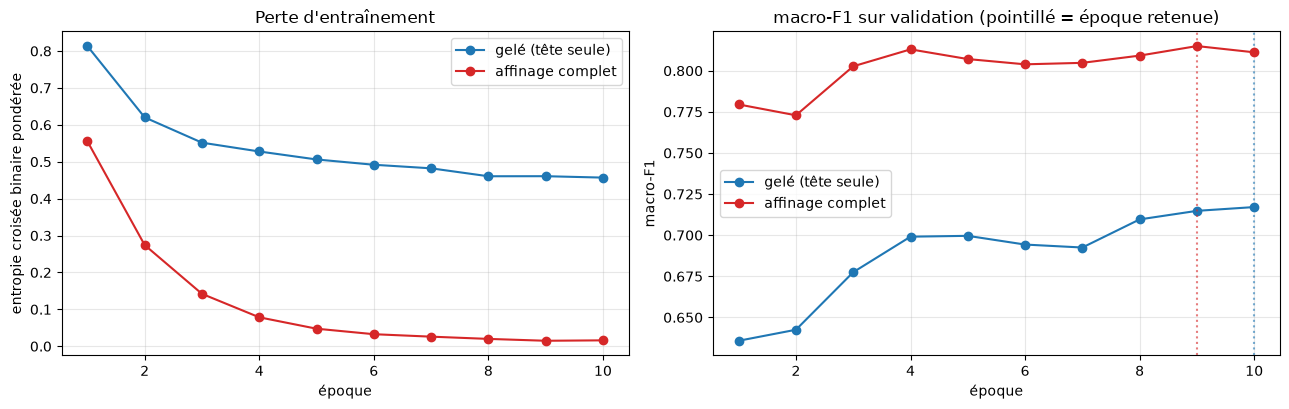

perte_train  macro_f1_val  micro_f1_val  duree_s
modele   epoch                                                  
gelé     1           0.8134        0.6358        0.6256  33.9084
         2           0.6201        0.6425        0.6370  33.6212
         3           0.5516        0.6775        0.6770  33.9112
         4           0.5278        0.6991        0.7047  33.5685
         5           0.5062        0.6996        0.7064  33.6419
         6           0.4918        0.6943        0.6927  33.6043
         7           0.4821        0.6925        0.7018  33.5692
         8           0.4606        0.7096        0.7052  33.7580
         9           0.4608        0.7148        0.7186  33.6842
         10          0.4570        0.7171        0.7173  33.5419
affinage 1           0.5553        0.7795        0.7813  44.7894
         2           0.2742        0.7729        0.7643  44.5342
         3           0.1420        0.8027        0.8033  44.5472
         4           0.0785        0.8130        0.8056  44.3746
         5           0.0476        0.8071        0.8061  44.2892
         6           0.0327        0.8039        0.7965  44.2869
         7           0.0260        0.8048        0.8027  44.2313
         8           0.0199        0.8092        0.8103  44.3009
         9           0.0149        0.8150        0.8021  44.6694
         10          0.0160        0.8112        0.8036  44.2287

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for nom, res, couleur in (("gelé (tête seule)", res_gele, "tab:blue"),
                          ("affinage complet", res_affine, "tab:red")):
    h = res["historique"]
    axes[0].plot(h["epoch"], h["perte_train"], marker="o", color=couleur, label=nom)
    axes[1].plot(h["epoch"], h["macro_f1_val"], marker="o", color=couleur, label=nom)
    axes[1].axvline(res["meilleur_epoch"], color=couleur, ls=":", alpha=.6)

axes[0].set(title="Perte d'entraînement", xlabel="époque", ylabel="entropie croisée binaire pondérée")
axes[1].set(title="macro-F1 sur validation (pointillé = époque retenue)", xlabel="époque", ylabel="macro-F1")
for a in axes: a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

pd.concat([res_gele["historique"].assign(modele="gelé"),
           res_affine["historique"].assign(modele="affinage")]).set_index(["modele", "epoch"]).round(4)

## 6. Tableau de synthèse — la référence de la phase 1

`macro-F1` arbitre. `micro-F1` en secondaire : l'écart entre les deux mesure à quel point une classe
rare est sacrifiée.

In [9]:
synthese = pd.DataFrame(lignes_synthese).set_index("modèle")
synthese["écart macro/micro"] = (synthese["micro-F1"] - synthese["macro-F1"]).round(4)
synthese

,macro-F1,micro-F1,F1 dent,F1 scratch,F1 crack,F1 glass shatter,F1 lamp broken,F1 tire flat,durée/époque (s),écart macro/micro
modèle,,,,,,,,,,
plancher : toujours_oui,0.3791,0.4058,0.6059,0.6946,0.2618,0.2839,0.2929,0.1358,NaN,0.0267
plancher : frequences,0.2593,0.3765,0.4706,0.5438,0.1890,0.1423,0.1418,0.0684,NaN,0.1172
ResNet18 gelé (tête seule),0.7171,0.7173,0.7286,0.7633,0.5119,0.8935,0.6108,0.7945,33.7,0.0002
ResNet18 affinage complet,0.8150,0.8021,0.7791,0.8177,0.6292,0.9699,0.7633,0.9310,44.4,-0.0129


## 7. Matrice de co-occurrence — quelles classes se confondent

En multi-étiquette, la matrice de confusion classique n'a pas de sens : une image peut porter
plusieurs classes vraies et déclencher plusieurs prédictions. On lit donc les co-occurrences :
lignes = ce qui est réellement présent, colonnes = ce que le modèle a prédit. La diagonale compte
les vrais positifs ; le hors-diagonale révèle les confusions systématiques.

In [10]:
meilleur_nom = synthese["macro-F1"].idxmax()
probas_best = probas_affine if "affinage" in meilleur_nom else probas_gele
print("meilleur modèle :", meilleur_nom)
tc.cooccurrence(probas_best, cibles)

meilleur modèle : ResNet18 affinage complet


,préd:dent,préd:scratch,préd:crack,préd:glass shatter,préd:lamp broken,préd:tire flat
vrai:dent,268,188,81,20,86,9
vrai:scratch,184,352,81,4,81,10
vrai:crack,68,77,84,1,46,6
vrai:glass shatter,9,3,3,129,4,1
vrai:lamp broken,83,72,59,0,108,3
vrai:tire flat,11,8,2,0,1,54


## 8. Lecture qualitative — regarder les erreurs

Un tableau ne dit pas *pourquoi* ça rate. On affiche des cas où le modèle se trompe : la cause
(dégât minuscule, reflet pris pour une rayure, photo d'intérieur) orientera le choix des leviers.

352 images de validation sur 810 portent au moins une erreur (43 %)


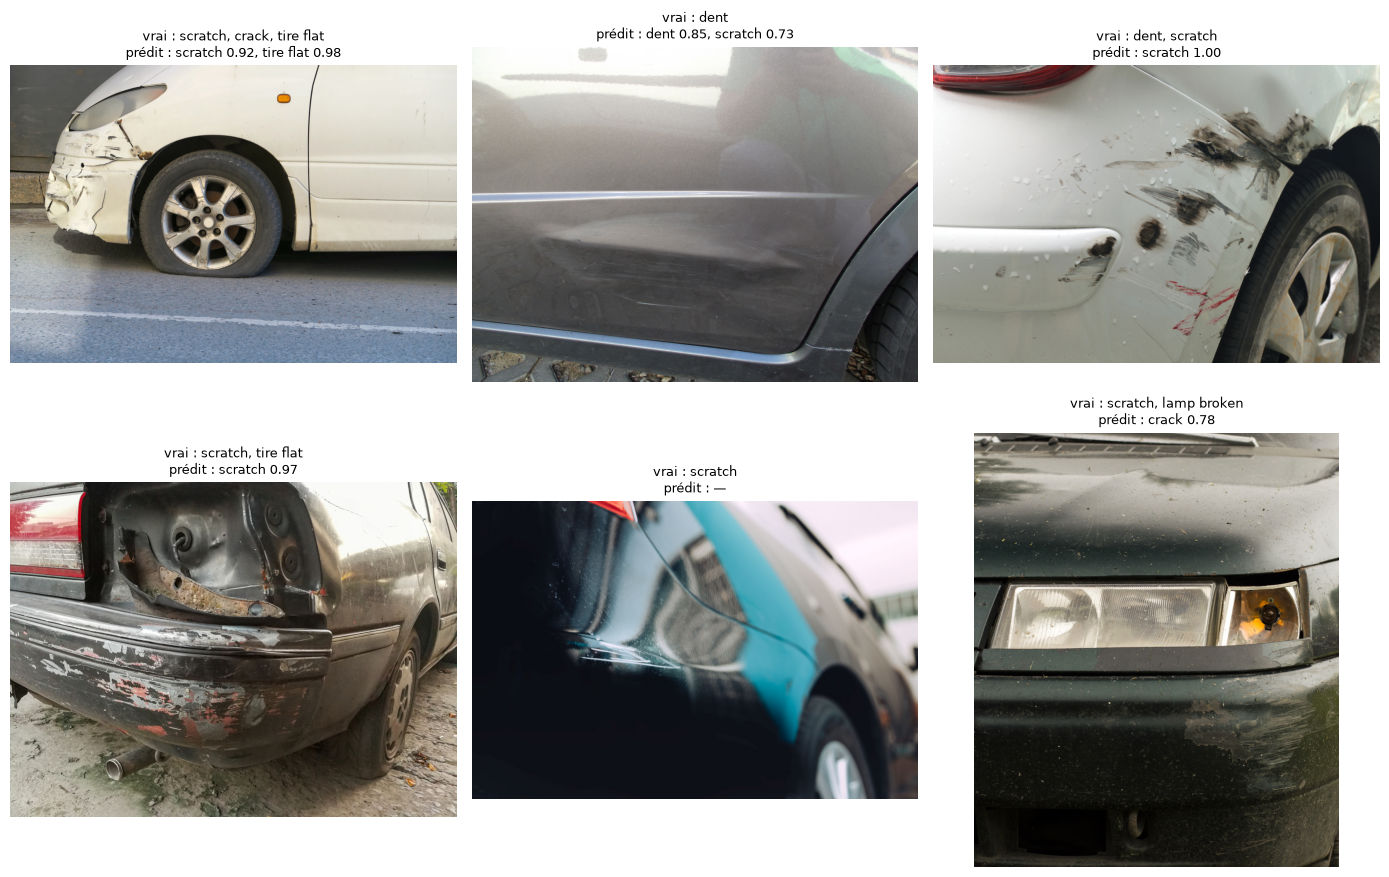

In [11]:
seuil = 0.5
preds_bin = (probas_best >= seuil).astype(int)
erreurs = np.where((preds_bin != cibles).any(axis=1))[0]
rng = np.random.default_rng(GRAINE)
choix = rng.choice(erreurs, size=min(6, len(erreurs)), replace=False)
print(f"{len(erreurs)} images de validation sur {len(cibles)} portent au moins une erreur "
      f"({len(erreurs)/len(cibles)*100:.0f} %)")

from PIL import Image
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, idx in zip(axes.ravel(), choix):
    iid = val_ds.ids[idx]
    ax.imshow(Image.open(val_ds.img_dir / val_ds.files[iid]).convert("RGB"))
    vrai = [c for c, v in zip(CLASSES, cibles[idx]) if v]
    pred = [f"{c} {probas_best[idx][i]:.2f}" for i, c in enumerate(CLASSES) if preds_bin[idx][i]]
    ax.set_title(f"vrai : {', '.join(vrai) or '—'}\nprédit : {', '.join(pred) or '—'}", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

## 9. Checkpoint — et vérification qu'il se recharge à l'identique

On sauvegarde les poids de la meilleure époque de l'affinage complet, avec la liste des classes,
les seuils et la configuration : l'inférence n'a rien à deviner. La phase 2 pourra rejouer les
seuils par classe sur des probabilités déjà calculées, sans réentraîner.

Le contrôle qui compte : les probabilités du modèle rechargé doivent être **identiques** à celles
du modèle en mémoire. Sinon le fichier ne sert à rien.

In [12]:
config = {"arch": "resnet18", "taille": TAILLE, "lots": LOTS, "epoques": EPOQUES,
          "lr": 1e-4, "gele": False, "graine": GRAINE,
          "meilleur_epoch": res_affine["meilleur_epoch"],
          "macro_f1_val": res_affine["meilleur_macro_f1"]}
chemin = tc.sauver_checkpoint("../../models/cardd_baseline.pt",
                              res_affine["best_state_dict"], config, seuils=seuil)
print("écrit :", chemin, f"({chemin.stat().st_size/1e6:.1f} Mo)")

modele_recharge, meta = tc.charger_checkpoint(chemin, device)
probas_recharge, _ = tc.predict_probas(modele_recharge, val_loader, device)
ecart_max = float(np.abs(probas_recharge - probas_affine).max())
print("classes :", meta["classes"], "| seuils :", meta["seuils"])
print(f"écart maximal des probabilités après rechargement : {ecart_max:.2e}")
assert ecart_max < 1e-5, "le checkpoint ne reproduit pas les mêmes probabilités"

écrit : ../../models/cardd_baseline.pt (44.8 Mo)


classes : ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat'] | seuils : 0.5
écart maximal des probabilités après rechargement : 0.00e+00


## 10. Conclusion — la référence de la phase 1

| modèle | macro-F1 | micro-F1 | durée/époque |
|---|---|---|---|
| plancher « toujours oui » | 0,379 | 0,406 | — |
| plancher « fréquences » | 0,259 | 0,377 | — |
| ResNet18 backbone gelé (tête seule) | 0,717 | 0,717 | 34 s |
| **ResNet18 affinage complet** | **0,815** | 0,802 | 44 s |

**Ce que les trois lignes démontrent.** Les filtres ImageNet utilisés tels quels, avec seulement
3 078 paramètres entraînés sur 11,2 millions (0,03 %), font déjà passer le macro-F1 de 0,379 à
0,717 : le transfert d'apprentissage fait l'essentiel du travail. Adapter ces filtres à la tôle
peinte (affinage complet) ajoute 0,098, pour 30 % de temps en plus par époque. L'affinage vaut son
coût, et c'est mesuré plutôt que supposé.

**Le surapprentissage est là, visible, mais sans dégât.** La perte d'entraînement de l'affinage
tombe de 0,555 à 0,016 : le réseau mémorise les 2 816 photos. Pourtant le macro-F1 sur validation
plafonne dès l'époque 3-4 (~0,80) et **ne s'effondre pas** — il oscille entre 0,804 et 0,815. Ce
profil (train mémorisé, validation stable) dit qu'il reste de la marge du côté de la
régularisation : c'est l'argument pour le levier d'augmentation de données.

**Aucune classe n'a été sacrifiée.** L'écart macro/micro est de −0,013 sur l'affinage, contre
+0,117 sur le plancher aléatoire. `tire flat` — 219 images d'entraînement seulement, `pos_weight`
= 11,86 — atteint F1 = 0,931, le deuxième meilleur score. La pondération de la perte a fait son
travail : le réseau n'a pas abandonné les classes rares.

**La classe qui coince : `crack` (fissure), F1 = 0,629**, avec une précision de 0,579 contre un
rappel de 0,689. La matrice de co-occurrence montre où : le modèle prédit `crack` sur 81 images
qui portent une bosse et 81 qui portent une rayure. Hypothèse — une fissure est un motif **fin et
allongé** ; sur une photo redimensionnée de 1000 px à 224 px, elle se réduit à quelques pixels et
devient indistinguable d'une éraflure. `lamp broken` (0,763) et `dent` (0,779) suivent le même
profil de confusion mutuelle.

**Deux limites de méthode à assumer.**
1. La ligne « gelé » **n'a pas atteint son plateau** : son meilleur macro-F1 est à l'époque 10, la
   dernière. Le budget fixe de 10 époques la sous-évalue. L'écart affinage/gelé réel est donc un
   peu plus faible que 0,098 — la comparaison reste équitable à budget égal, mais elle sous-estime
   le backbone gelé.
2. **Le coût est dominé par le chargement des images**, pas par le calcul : 29 s de décodage JPEG
   mesurés par époque, contre 4 s de calcul en gelé et 15 s en affinage. Conséquence directe pour
   la phase 2 : à 224 px, **basculer sur le PC RTX 5070 Ti n'apporterait presque rien**. La bascule
   ne redevient rentable qu'au levier résolution 384 px, où le calcul reprend le dessus.

**Ordre des leviers que ces résultats suggèrent** (à valider au gate) : résolution d'abord (elle
attaque directement l'échec sur `crack`), puis seuils par classe (la précision 0,579 contre rappel
0,689 sur `crack` est un déséquilibre de seuil, gratuit à corriger), puis augmentation (le
surapprentissage visible), et ResNet50 en dernier — un réseau qui mémorise déjà à 11 millions de
paramètres n'a pas un besoin évident de 25 millions.

**Gate.** On s'arrête ici. Chaque levier de la phase 2 sera mesuré **seul** contre ce tableau.

Limites à porter au dossier de certification :
- absence de fuite vérifiée par nom de fichier et empreinte md5 seulement — la même voiture
  photographiée sous un autre angle dans deux découpages ne serait pas détectée ;
- CarDD ne contient que des **gros plans de dégâts** : ce 0,815 ne prouve rien sur une photo
  d'annonce complète, où le dégât occupe une fraction du cadre. C'est l'objet du test sur photos
  leboncoin, après le gate ;
- aucune voiture intacte dans le jeu : la moitié « pas abîmé » du binaire dérivé n'est pas
  entraînée, seulement testable ;
- 43 % des images de validation portent au moins une erreur au seuil 0,5, alors que le macro-F1
  vaut 0,815 : la métrique par classe est indulgente comparée à une exigence « toutes les
  étiquettes justes sur l'image ». À dire tel quel plutôt que d'annoncer le seul 0,815.